# How do you pick a forgetting strategy?

A Bayesian linear model never forgets. Every observation adds to the
posterior precision, so after ten thousand rewards the model is nearly
certain about its coefficients. That is exactly what we want when the
world holds still. When it does not, the model has a problem: a change in
the reward has to outvote every observation that came before it, and the
more the model has seen, the longer that takes.

Forgetting fixes this by widening the posterior so that new observations
count for more. But "forget" is not one operation. `bayesianbandits`
ships four forgetting rules, and they can be triggered by two different
events:

- **An update.** Passing `forgetting=` to an estimator makes it forget a
  little before every batch it absorbs. This is forgetting *because we
  observed something*.
- **A tick of the clock.** Calling `decay()` on an agent or estimator
  forgets on a schedule of your choosing, whether or not any observations
  arrived. This is forgetting *because time passed*.

In this notebook we work through which rule belongs on which event, and
why. The short version is that the answer depends on what you believe is
changing: the arms you keep pulling, or every arm, whether you look at it
or not. The [math reference](../math/forgetting.rst) has the equations
behind each rule; here we look at what they do to a posterior.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.linalg import cho_factor, cho_solve

from bayesianbandits import (
    ExponentialForgetting,
    FeatureWiseForgetting,
    NormalRegressor,
    SiftForgetting,
    StabilizedForgetting,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ALPHA = 1.0  # prior precision
BETA = 4.0  # noise precision (noise sd 0.5)


def forget(rule, R, x):
    # The rule returns the forgotten precision (and an effective batch we do not need).
    # Dense rules maintain only the upper triangle, as the estimators do.
    out = rule.update(R, x[None, :], np.zeros(1), alpha=ALPHA)
    R_bar = R if out is None else out[0]
    return np.triu(R_bar) + np.triu(R_bar, 1).T


def absorb(R_bar, theta, x, y):
    # Conjugate update from the forgotten precision.
    R_new = R_bar + BETA * np.outer(x, x)
    theta_new = cho_solve(cho_factor(R_new), R_bar @ theta + BETA * x * y)
    return R_new, theta_new


def covariance(R):
    return cho_solve(cho_factor(R), np.eye(len(R)))

## Why forget at all?

Let's start with the simplest possible case: one arm, one coefficient,
which is just the arm's mean reward. Halfway through the run the true
mean drops from 1.0 to 0.0. We'll fit the posterior two ways: with no
forgetting, and with the simplest rule, `ExponentialForgetting`, which
multiplies the whole precision matrix by $\gamma = 0.98$ before each
observation.

The helpers in the cell above do one conjugate update by hand so we can
watch the precision directly. `forget` applies a rule to the current
precision, and `absorb` adds the observation to the result.

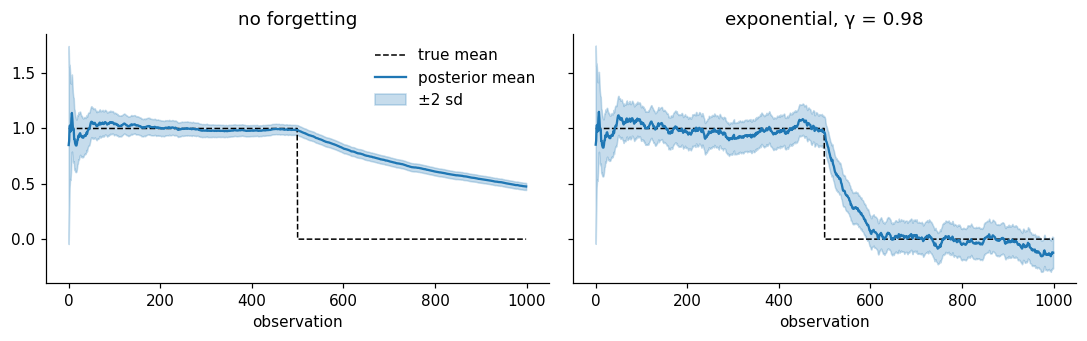

In [2]:
rng = np.random.default_rng(0)
T, SHIFT = 1000, 500
truth = np.where(np.arange(T) < SHIFT, 1.0, 0.0)
rewards = truth + rng.normal(0, 0.5, T)
x1 = np.array([1.0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, rule in zip(axes, [None, ExponentialForgetting(0.98)]):
    R, theta = ALPHA * np.eye(1), np.zeros(1)
    means, sds = [], []
    for t in range(T):
        R_bar = R if rule is None else forget(rule, R, x1)
        R, theta = absorb(R_bar, theta, x1, rewards[t])
        means.append(theta[0])
        sds.append(np.sqrt(covariance(R)[0, 0]))
    means, sds = np.array(means), np.array(sds)
    ax.plot(truth, color="k", lw=1, ls="--", label="true mean")
    ax.plot(means, color="C0", label="posterior mean")
    ax.fill_between(
        np.arange(T),
        means - 2 * sds,
        means + 2 * sds,
        color="C0",
        alpha=0.25,
        label="±2 sd",
    )
    ax.set_title("no forgetting" if rule is None else "exponential, γ = 0.98")
    ax.set_xlabel("observation")
axes[0].legend(loc="upper right", frameon=False)
plt.tight_layout()

Without forgetting, the posterior has collapsed to a narrow band by the
time the change arrives, and the mean crawls toward the new value. It
has five hundred old observations to outvote, and after five hundred new
ones it is only halfway there. With exponential forgetting the posterior
width stops shrinking at a floor, because each observation adds about as
much precision as the rule removes, and the mean tracks the change within
a few dozen observations.

This is the whole case for forgetting. The rest of the notebook is about
what goes wrong when we apply this rule to a model with more than one
coefficient.

## Uneven excitation

Exponential forgetting worked above for a reason that is easy to miss:
every observation excites the one coefficient, so the precision removed
before each row is put back by the row. In a bandit that is not true. A
policy that has settled on an arm pulls it most of the time and the other
arms rarely, so most rows say nothing about most of the model.

To see what that does, we'll use the model a shared learner actually
fits: an intercept column plus a one-hot column per arm, so that arm $a$
has expected reward $\mu + \tau_a$. Statisticians will recognize this as
a one-way ANOVA. We'll pull arm 0 90% of the time and arms 1 and 2 5%
each, on a fixed schedule, so that the only thing that differs between
runs is the forgetting rule.

Two directions in this model are poorly excited.

1. **The rare arms' cell means.** The model learns about $\mu + \tau_1$
   only when arm 1 is pulled, one observation in twenty. Every one of arm
   0's pulls carries no information about arm 1, but still removes a
   fraction $1 - \gamma$ of that precision.
2. **The unidentified direction.** An intercept plus a full set of one-hot
   columns is overparameterized, which is why a statistician would drop a
   level or impose a sum-to-zero constraint. Add a constant $c$ to $\mu$
   and subtract it from every $\tau_a$: no cell mean changes, so no
   observation can ever tell the difference. A ridge prior resolves the
   overparameterization instead of a constraint, so only the prior pins
   this direction down, and exponential forgetting shrinks the prior's
   contribution by $\gamma$ on every observation, forever.

Precision that is removed and never replaced decays to zero, and the
corresponding variance grows without bound. The recursive least squares
literature calls this *covariance windup*, and it is the reason the other
three rules exist. Let's run the same 2000 pulls under each rule at
$\gamma = 0.98$ and track two things: the posterior standard deviation of
arm 1's cell mean, and the posterior variance along the unidentified
direction.

ExponentialForgetting: Cholesky failed at observation 1575


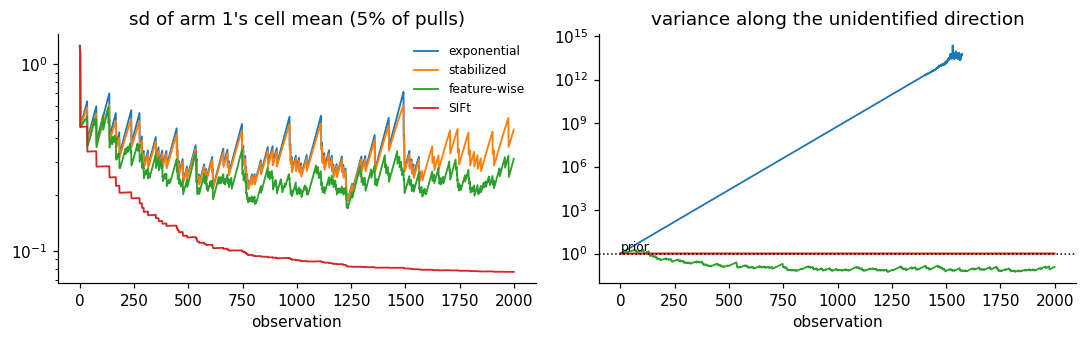

In [3]:
rng = np.random.default_rng(1)
T, GAMMA = 2000, 0.98
P_PULL = np.array([0.9, 0.05, 0.05])
ARM_MEANS = np.array([1.0, 0.5, 0.0])
arms = rng.choice(3, size=T, p=P_PULL)
rewards = ARM_MEANS[arms] + rng.normal(0, 0.5, T)

ROWS = np.hstack([np.ones((3, 1)), np.eye(3)])  # intercept + one-hot
UNIDENTIFIED = np.array([1.0, -1.0, -1.0, -1.0]) / 2  # mu up, every tau down

RULES = {
    "exponential": ExponentialForgetting(GAMMA),
    "stabilized": StabilizedForgetting(GAMMA),
    "feature-wise": FeatureWiseForgetting(GAMMA),
    "SIFt": SiftForgetting(GAMMA),
}


def run(rule):
    R, theta = ALPHA * np.eye(4), np.zeros(4)
    arm1_sd, unid_var = np.full(T, np.nan), np.full(T, np.nan)
    for t in range(T):
        x = ROWS[arms[t]]
        try:
            R, theta = absorb(forget(rule, R, x), theta, x, rewards[t])
        except np.linalg.LinAlgError:
            print(f"{type(rule).__name__}: Cholesky failed at observation {t}")
            break
        S = covariance(R)
        arm1_sd[t] = np.sqrt(ROWS[1] @ S @ ROWS[1])
        unid_var[t] = UNIDENTIFIED @ S @ UNIDENTIFIED
    return arm1_sd, unid_var


results = {name: run(rule) for name, rule in RULES.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for name, (arm1_sd, unid_var) in results.items():
    axes[0].plot(arm1_sd, label=name, lw=1.2)
    axes[1].plot(unid_var, label=name, lw=1.2)
axes[0].set_title("sd of arm 1's cell mean (5% of pulls)")
axes[1].set_title("variance along the unidentified direction")
axes[1].axhline(1 / ALPHA, color="k", ls=":", lw=1)
axes[1].text(0, 1.4 / ALPHA, "prior", fontsize=8)
for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("observation")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()

**What to notice:**

- **Exponential forgetting winds up in both directions.** In the left
  panel, arm 1's uncertainty climbs during every stretch of arm 0 pulls
  and drops only when arm 1 itself is pulled. In the right panel the
  variance along the unidentified direction grows by fourteen orders of
  magnitude, until at
  observation 1575 the precision matrix is so ill-conditioned that the
  Cholesky factorization fails. Every prediction was fine right up to
  that point, because predictions depend only on cell means, which are
  identified.
- **Stabilized forgetting puts a floor under the windup.**
  `StabilizedForgetting` (Kulhavý and Zarrop, 1993) adds
  $(1 - \gamma)\alpha$ back onto the diagonal after scaling, so no
  direction can decay past the prior precision $\alpha$. The unidentified
  direction sits exactly on the prior line. But the floor does not remove the cause:
  arm 1 is still forgotten on arm 0's pulls, all the way down to the
  prior. This is the rule the empirical Bayes estimators use, and the one
  we will come back to for the clock.
- **The two directional rules do not wind up at all.** That is the
  subject of the next section.

## Forget only what new data replaces

Kulhavý and Kárný (1984) put the fix as a principle: only forget
information that the new data is about to replace. A pull of arm 0
informs one direction, arm 0's cell mean, so that is the only direction
that should pay for it. Two rules in `bayesianbandits` do this.

- **`SiftForgetting`** (Lai and Bernstein, 2024) subtracts a rank-one term
  along $\Lambda x$, which is exactly the direction the row is about to
  refill. Everything orthogonal to it is left alone.
- **`FeatureWiseForgetting`** is the vector forgetting of Saelid and Foss
  (1983): it scales the coordinates that appear in the row and leaves the
  others untouched.

In the figure above neither rule winds up. Arm 1 keeps the precision its
own pulls earned, and the unidentified direction never drifts far from
where the prior put it. The two rules do differ, and the difference is in the shared
intercept column. Feature-wise forgets $\mu$ coordinate by coordinate on
every pull, which loosens the rare arms' cell means more than SIFt does
and nudges the unidentified direction away from the prior. The math
reference works
through why. In practice, though, the choice between them is usually made
by something else entirely: whether your model is sparse.

### SIFt fills in sparse models

Think about a sparse model with an intercept, a column per arm, and a
column per arm-by-segment cell. The precision matrix has a nonzero
wherever two features have appeared in the same row, so its pattern is a
star: the intercept touches everything, each arm touches its own cells,
and the cells touch nothing else. It stays a star however many
observations arrive, and the sparse Cholesky factorization stays cheap.

Exponential, stabilized and feature-wise forgetting all scale entries of
$\Lambda$ in place, so they cannot change that pattern. SIFt subtracts
$\Lambda x x^\top \Lambda$, and the vector $\Lambda x$ is nonzero on every
feature that has ever shared a row with the observed ones. With a shared
intercept, that is every feature the model has seen. Let's count the
nonzeros in $\Lambda$ as observations arrive, using the same rule objects
on a sparse precision matrix with 50 arms and 10 segments per arm.

exponential   nnz after 400 observations:    1767  (0.6% dense)
feature-wise  nnz after 400 observations:    1767  (0.6% dense)
SIFt          nnz after 400 observations:  109121  (35.9% dense)


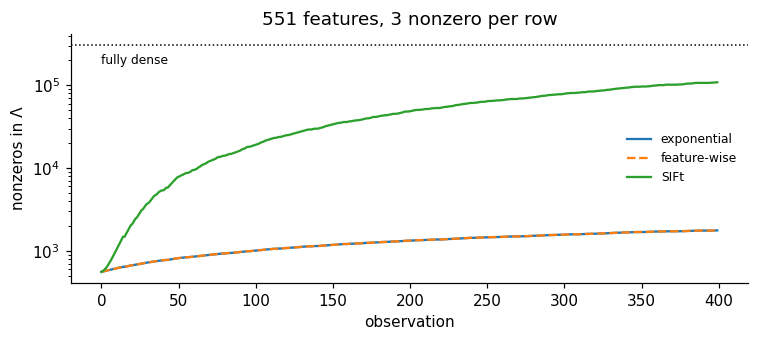

In [4]:
N_ARMS, N_SEG = 50, 10
P = 1 + N_ARMS + N_ARMS * N_SEG
rng = np.random.default_rng(2)


def sparse_row(arm, seg):
    cols = [0, 1 + arm, 1 + N_ARMS + arm * N_SEG + seg]
    return sparse.csc_array((np.ones(3), ([0, 0, 0], cols)), shape=(1, P))


T_SPARSE = 400
draws = [(rng.integers(N_ARMS), rng.integers(N_SEG)) for _ in range(T_SPARSE)]
nnz = {}
for name in ["exponential", "feature-wise", "SIFt"]:
    R = sparse.csc_array(ALPHA * sparse.eye(P))
    counts = []
    for arm, seg in draws:
        X = sparse_row(arm, seg)
        R_bar, _, _ = RULES[name].update(R, X, np.zeros(1), alpha=ALPHA)
        R = sparse.csc_array(R_bar + BETA * (X.T @ X))
        R.eliminate_zeros()
        counts.append(R.nnz)
    nnz[name] = np.array(counts)

fig, ax = plt.subplots(figsize=(7, 3.2))
for name, counts in nnz.items():
    ax.plot(counts, label=name, lw=1.5, ls="--" if name == "feature-wise" else "-")
ax.axhline(P * P, color="k", ls=":", lw=1)
ax.text(0, P * P * 0.8, "fully dense", fontsize=8, va="top")
ax.set_yscale("log")
ax.set_xlabel("observation")
ax.set_ylabel("nonzeros in Λ")
ax.set_title(f"{P} features, 3 nonzero per row")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
for name, counts in nnz.items():
    print(
        f"{name:13s} nnz after {T_SPARSE} observations: {counts[-1]:>7d}  ({counts[-1] / P**2:.1%} dense)"
    )

The exponential and feature-wise curves lie on top of each other: the
pattern is whatever the data made it. SIFt's curve grows with the square
of the number of features seen so far, and at this size it is more than
a third of the way to fully dense after 400 observations. At a million
features, which is where the sparse estimators are meant to run, that is
not a slowdown but a memory failure. This is why the library treats SIFt
as a dense-model rule and feature-wise as the directional rule for sparse
models; the sparse estimators refuse `SiftForgetting` outright.

## Untouched is also a claim

So far the directional rules look strictly better: no windup, and the
rare arms keep what they learned. But notice what they promise about an
arm that is not being pulled: nothing changes. That is the right promise
if an arm's reward only changes when we observe it, and the wrong one if
it changes with time. An arm the policy stopped pulling keeps a posterior
that says "this arm is bad", nothing on the update event will ever widen
it, and so the policy never goes back to check.

That is what the second event is for. A tick of the clock should widen
every direction, because time passed for every direction, and it should
widen toward the prior rather than toward nothing, or the arms we are not
pulling wind up just as in the first figure. In `bayesianbandits` that is
`decay()` with `StabilizedForgetting`, called once per unit of time.

Let's make this concrete with an actual policy. We'll run Thompson
sampling on the same three-arm model, this time through
`NormalRegressor`'s public API. Arm 2 starts as the worst arm, and at
round 1000 it quietly becomes the best. We compare three learners: no
forgetting at all, feature-wise on the update event, and a stabilized
tick every 25 rounds.

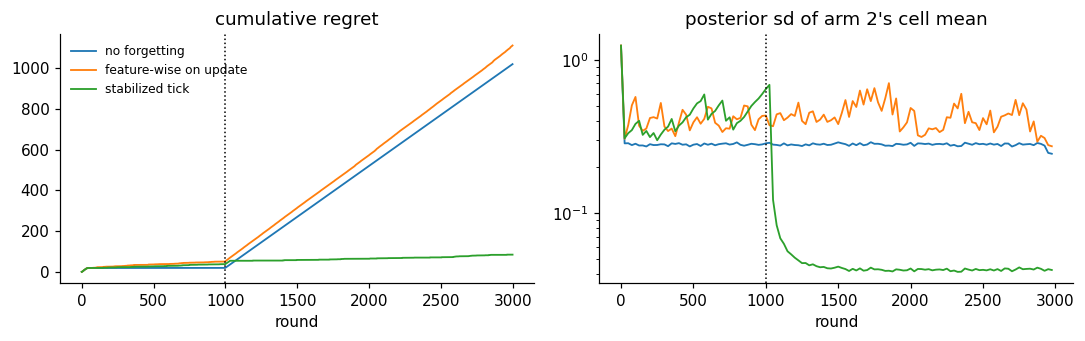

In [5]:
T, CHANGE, EVERY = 3000, 1000, 25
TRUE = np.where(np.arange(T)[:, None] < CHANGE, [1.0, 0.5, 0.0], [1.0, 0.5, 1.5])


def thompson(forgetting=None, tick=None, seed=3):
    rng = np.random.default_rng(seed)
    model = NormalRegressor(
        alpha=ALPHA, beta=BETA, forgetting=forgetting, random_state=seed
    )
    regret, arm2_sd = np.zeros(T), np.full(T, np.nan)
    for t in range(T):
        a = int(np.argmax(model.sample(ROWS)))
        model.partial_fit(ROWS[a : a + 1], np.array([TRUE[t, a] + rng.normal(0, 0.5)]))
        regret[t] = TRUE[t].max() - TRUE[t, a]
        if tick is not None and (t + 1) % EVERY == 0:
            model.decay(tick)
        if t % EVERY == 0:
            arm2_sd[t] = model.sample(ROWS[2:3], size=2000).std()
    return np.cumsum(regret), arm2_sd


learners = {
    "no forgetting": thompson(),
    "feature-wise on update": thompson(forgetting=FeatureWiseForgetting(0.98)),
    "stabilized tick": thompson(tick=StabilizedForgetting(0.85)),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for name, (regret, arm2_sd) in learners.items():
    axes[0].plot(regret, label=name, lw=1.2)
    ok = ~np.isnan(arm2_sd)
    axes[1].plot(np.flatnonzero(ok), arm2_sd[ok], label=name, lw=1.2)
for ax in axes:
    ax.axvline(CHANGE, color="k", ls=":", lw=1)
    ax.set_xlabel("round")
axes[0].set_title("cumulative regret")
axes[1].set_title("posterior sd of arm 2's cell mean")
axes[1].set_yscale("log")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()

**What to notice:**

- **No forgetting never finds the change.** Arm 2 was pulled a handful of
  times early on, its posterior settled on "bad arm", and after that
  Thompson sampling almost never draws it. Regret grows linearly after
  round 1000.
- **Feature-wise on the update event does no better.** It forgets arm 2
  only on arm 2's own pulls, and those have stopped. In the right panel
  its uncertainty about arm 2 wanders but never opens up.
- **The stabilized tick finds it.** Between pulls, arm 2's posterior
  widens toward the prior. Within a few hundred rounds of the change
  Thompson sampling draws arm 2 again, sees the new reward, and the
  regret curve flattens.

The tick is what the calendar needs. The update rule is for change that
arrives with the observation, and nothing in this simulation changes when
an arm is observed.

## Could you need both?

Nothing stops you from putting a directional rule on the estimator and a
stabilized tick on the clock, and there is a well-known precedent for
doing so. TrueSkill 2 (Minka et al., 2018) found that a player's skill
moves both per match played and per day away from the game, and fits the
two rates separately.

Before doing the same, weigh what it costs. A second rule is a second
forgetting rate, and the two are hard to tune apart. In a bandit you
observe what you pull, so on the arm that matters the two clocks nearly
coincide, and a stabilized tick alone usually covers both kinds of
change. Reach for both when you have a reason to believe
the change per observation is real and observation volume is very uneven
across arms, so that no single tick rate can fit every arm.

## Both events in one agent

Whichever you choose, it is two lines. The rule passed to the estimator
forgets on every update, and the rule passed to `decay()` forgets when
you say the clock ticked; `steps=` raises its rate to a power if the job
missed a few.

In [6]:
from bayesianbandits import Arm, ContextualAgent, ThompsonSampling

arms = [
    Arm(
        a,
        learner=NormalRegressor(
            alpha=1.0, beta=4.0, forgetting=FeatureWiseForgetting(0.98)
        ),
    )
    for a in range(3)
]
agent = ContextualAgent(arms, ThompsonSampling(), random_seed=0)

X = np.ones((1, 1))
(action,) = agent.pull(X)
agent.update(X, np.array([1.0]))  # forgets along this row, then absorbs it

agent.decay(StabilizedForgetting(0.9), steps=2)  # two days passed
print(action, agent.arms[0].learner.forgetting)

2 FeatureWiseForgetting(rate=0.98)


## Choosing

Start from what you believe is changing.

| What moves | On the estimator | On the clock |
|---|---|---|
| Nothing you believe in | `forgetting=None` (default) | no `decay()` |
| Rewards drift with time | none | `decay(StabilizedForgetting(γ))` once per period |
| Rewards change when observed, dense model | `forgetting=SiftForgetting(γ)` | none |
| Rewards change when observed, sparse model | `forgetting=FeatureWiseForgetting(γ)` | none |
| Both, and you can tune two rates | a directional rule | a stabilized tick |
| Empirical Bayes estimators | uniform rules only; the floor is the tuned `alpha` | `decay()` is stabilized by default |

Two practical notes.

- **The same $\gamma$ means different amounts of forgetting.** Exponential
  removes a fraction $1 - \gamma$ of the precision in every direction at
  every step; feature-wise removes it only in the observed coordinates,
  and SIFt only along one direction. Expect to retune when you switch
  rules.
- **The default tick is still plain exponential** on everything except
  the empirical Bayes estimators, for compatibility. It is the right rule
  only when every direction is excited between ticks. Otherwise it is the
  second figure of this notebook.

## References

- Kulhavý, R. and Kárný, M. (1984). Tracking of slowly varying parameters
  by directional forgetting. *IFAC World Congress*.
- Kulhavý, R. and Zarrop, M. B. (1993). On a general concept of
  forgetting. *International Journal of Control* 58(4).
- Saelid, S. and Foss, B. (1983). Adaptive controllers with a vector
  variable forgetting factor. *IEEE CDC*.
- Vahidi, A., Stefanopoulou, A. and Peng, H. (2005). Recursive least
  squares with forgetting for online estimation of vehicle mass and road
  grade. *Vehicle System Dynamics* 43(1).
- Lai, B. and Bernstein, D. S. (2024). SIFt-RLS: Subspace of information
  forgetting recursive least squares. *arXiv:2404.10844*.
- Minka, T., Cleven, R. and Zaykov, Y. (2018). TrueSkill 2: an improved
  Bayesian skill rating system. *Microsoft Research technical report*.